In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pydicom

In [2]:
dicom_folder = Path(
    r"E:\My codes\Medical AI\lung-ai-platform\data\raw\lidc_idri\LIDC-IDRI-0001\2000-01-01-30178\3000566-03192"
)

In [3]:
dicom_files = list(
    dicom_folder.glob("*.dcm")
)

print(len(dicom_files))

133


In [4]:
datasets = [
    pydicom.dcmread(
        f,
        stop_before_pixels=True
    )
    for f in dicom_files
]

In [5]:
datasets.sort(
    key=lambda ds:
        float(
            ds.ImagePositionPatient[2]
        )
)

In [6]:
print(
    datasets[0].ImagePositionPatient
)

print(
    datasets[-1].ImagePositionPatient
)

[-166.000000, -171.699997, -340.000000]
[-166.000000, -171.699997, -10.000000]


In [7]:
slices = []

for ds in datasets:
    full_ds = pydicom.dcmread(
        ds.filename
    )

    slices.append(
        full_ds.pixel_array
    )

In [8]:
volume = np.stack(
    slices,
    axis=0
)

In [9]:
print(volume.shape)

(133, 512, 512)


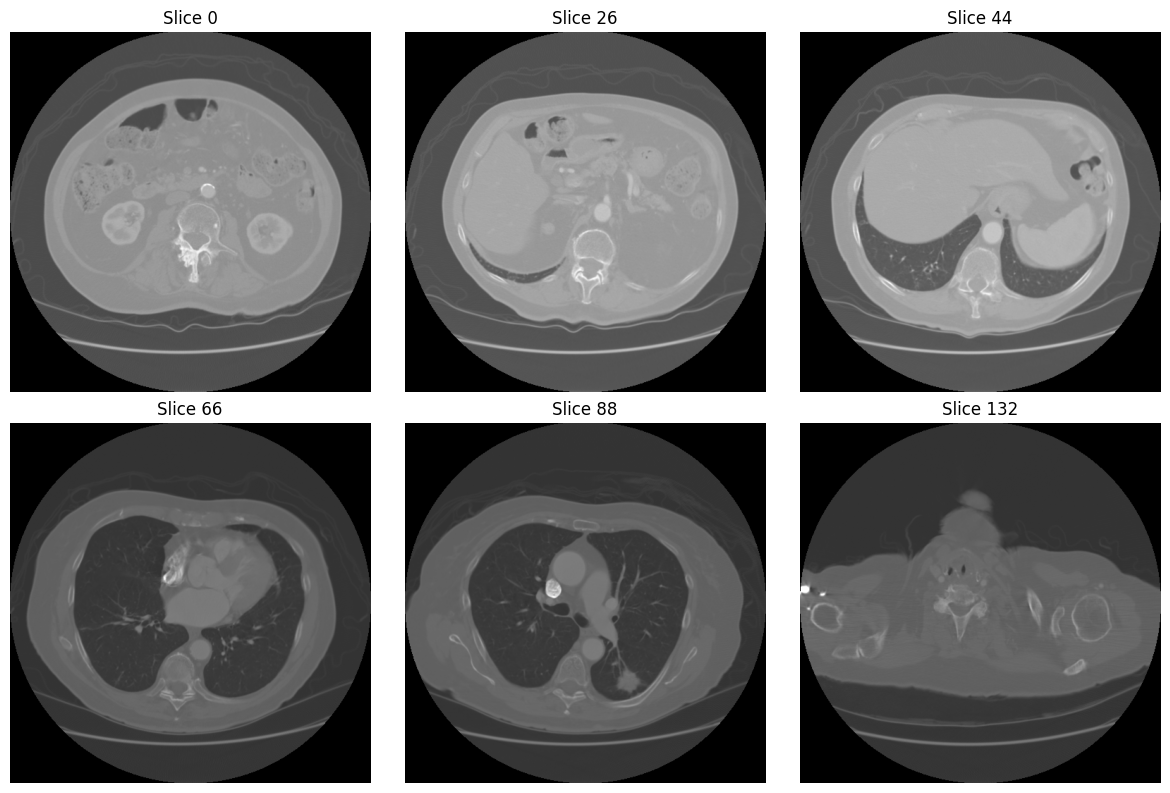

In [11]:
fig , axes = plt.subplots(2 , 3 , figsize=(12 , 8))

indices = [
    0,
    volume.shape[0]//5,
    volume.shape[0]//3,
    volume.shape[0]//2,
    volume.shape[0]*2//3,
    volume.shape[0]-1
]

for ax , idx in zip(axes.flat , indices):
    ax.imshow(volume[idx] , cmap='gray')
    ax.set_title(f'Slice {idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
z = volume.shape[0]//2
y = volume.shape[1]//2
x = volume.shape[2]//2

print(f'center slice (z): {z}')
print(f'center slice (y): {y}')
print(f'center slice (x): {x}')


center slice (z): 66
center slice (y): 256
center slice (x): 256


In [14]:
axial = volume[z, :, :]
coronal = volume[:, y, :]
sagittal = volume[:, :, x]

In [15]:
print('Axial shape :' , axial.shape)
print('coronal shape :' , coronal.shape)
print('sagittal shape :' , sagittal.shape)

Axial shape : (512, 512)
coronal shape : (133, 512)
sagittal shape : (133, 512)


In [17]:
pixel_spacing = datasets[0].PixelSpacing
slice_thickness = datasets[0].SliceThickness

print('pixel spacing:' , pixel_spacing)
print('slice thickness:' , slice_thickness)

pixel spacing: [0.703125, 0.703125]
slice thickness: 2.500000


In [18]:
axial_aspect = pixel_spacing[1] / pixel_spacing[0]
coronal_aspect = slice_thickness / pixel_spacing[0]
sagittal_aspect = slice_thickness / pixel_spacing[1]

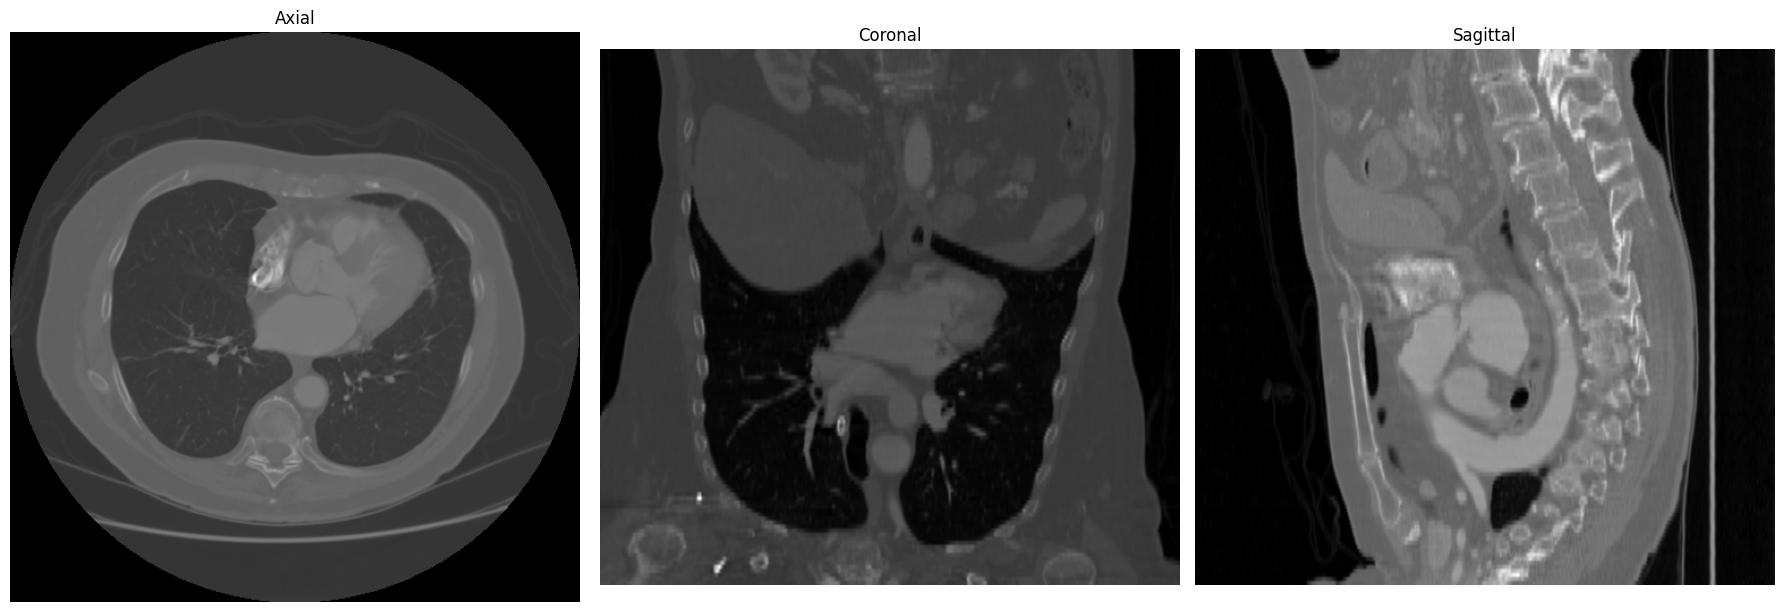

In [19]:
fig , axes = plt.subplots(1 , 3 , figsize=(18 , 6))

axes[0].imshow(axial, cmap='gray')
axes[0].set_aspect(axial_aspect)
axes[0].set_title('Axial')
axes[0].axis('off')

axes[1].imshow(coronal, cmap='gray')
axes[1].set_aspect(coronal_aspect)
axes[1].set_title('Coronal')
axes[1].axis('off')

axes[2].imshow(sagittal, cmap='gray')
axes[2].set_aspect(sagittal_aspect)
axes[2].set_title('Sagittal')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [23]:
class CtVolume:

    def __init__(self , dicom_folder):

        self.dicom_folder = Path(dicom_folder)

        self.datasets = None
        self.voluume = None

        self.pixel_spacing = None
        self.slice_thickness = None
        self.load()

    def load(self):

        dicom_files = list(self.dicom_folder.glob('*.dcm'))

        if len(dicom_files) == 0:
            raise FileNotFoundError('No DICOM files found.')
        
        datasets = [
            pydicom.dcmread(
                f,
                stop_before_pixels=True
            )
            for f in dicom_files
        ]

        datasets.sort(
            key=lambda ds: floaat(ds.ImagePositionPatient[2])
        )

        slices = []

        for ds in datasets:
            full_ds = pydicom.dcmread(ds.filename)
            slices.append(full_ds.pixel_array)
        self.datasets = datasets
        self.voluume = np.stack(slices , axis=0)
        self.pixel_spacing = datasets[0].PixelSpacing
        self.slice_thickness = float(
            datasets[0].SliceThickness
        )
    def __repr__(self):

        return (
            "CTVolume\n"
            "-------------------------\n"
            f"Slices          : {self.volume.shape[0]}\n"
            f"Rows            : {self.volume.shape[1]}\n"
            f"Columns         : {self.volume.shape[2]}\n"
            f"Pixel Spacing   : {self.pixel_spacing}\n"
            f"Slice Thickness : {self.slice_thickness} mm"
        )

    def shape(self):
        return self.volume.shape
    
    def axial(self , index):
        return self.volume[index]
    
    def coronal(self , index):
        return self.volume[: , index , :]
    
    def sagittal(self , index):
        return self.volume[: , : , index]
